In [ ]:
import zipfile
import os

zip_path = "/content/face_dataset.zip"

print(os.path.exists(zip_path))
print(os.path.getsize(zip_path))



with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/face_dataset/")

True
119094597


In [ ]:
!file /content/face_dataset.zip

/content/face_dataset.zip: Zip archive data, at least v2.0 to extract, compression method=store


In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import zipfile

try:

  with zipfile.ZipFile(zip_path,"r") as zip_ref:
    bad_file=zip_ref.testzip()
    if bad_file is None:
      print("it is a valid zip file")
    else:
      print("it is a corrupt zip file", bad_file)
except Exception as e:
  print(e)


it is a valid zip file


In [ ]:
!unzip -t /content/face_dataset.zip

Streaming output truncated to the last 5000 lines.
    testing: face_dataset/face_dataset/Pak_Gil_Yon/   OK
    testing: face_dataset/face_dataset/Pak_Gil_Yon/Pak_Gil_Yon_0001.jpg   OK
    testing: face_dataset/face_dataset/Pamela_Anderson/   OK
    testing: face_dataset/face_dataset/Pamela_Anderson/Pamela_Anderson_0001.jpg   OK
    testing: face_dataset/face_dataset/Pamela_Anderson/Pamela_Anderson_0002.jpg   OK
    testing: face_dataset/face_dataset/Pamela_Anderson/Pamela_Anderson_0003.jpg   OK
    testing: face_dataset/face_dataset/Pamela_Anderson/Pamela_Anderson_0004.jpg   OK
    testing: face_dataset/face_dataset/Pamela_Anderson/Pamela_Anderson_0005.jpg   OK
    testing: face_dataset/face_dataset/Pamela_Melroy/   OK
    testing: face_dataset/face_dataset/Pamela_Melroy/Pamela_Melroy_0001.jpg   OK
    testing: face_dataset/face_dataset/Paola_Espinoza/   OK
    testing: face_dataset/face_dataset/Paola_Espinoza/Paola_Espinoza_0001.jpg   OK
    testing: face_dataset/face_dataset/Parador

In [ ]:
import os

os.listdir("/content/face_dataset/face_dataset/face_dataset")

['Alyse_Beaupre',
 'Laura_Bozzo',
 'Dan_Quayle',
 'Alma_Powell',
 'Gabrielle_Rose',
 'Placido_Domingo',
 'Irwan_Fadzi_Idris',
 'Wang_Yingfan',
 'Saeb_Erekat',
 'Michael_McNeely',
 'Kyra_Sedgwick',
 'Phoenix_Chang',
 'Roy_Halladay',
 'Cristina_Kirchner',
 'Ken_Loach',
 'Dwayne_Johnson',
 'Shania_Twain',
 'Mark_Polansky',
 'Tuncay_Sanli',
 'Stephen_Friedman',
 'Jake_Brace',
 'James_Hakett',
 'Eddie_Lewis',
 'Guennadi_Chipouline',
 'Larry_Thompson',
 'Edward_Arsenault',
 'Janusz_Kaminski',
 'Kent_Robinson',
 'Antonio_Palocci',
 'Daniel_Coats',
 'Charlie_Sheen',
 'Jong_Thae_Hwa',
 'Jay_Garner',
 'Georgina_Bardach',
 'Elena_Bereznaya',
 'Pauley_Perrette',
 'Artieas_Shanks',
 'Gary_Marshall',
 'Christine_Baumgartner',
 'Lucas_Wysocki',
 'Elijan_Ingram',
 'Javier_Bardem',
 'Elizabeth_Taylor',
 'Brady_Rodgers',
 'Juan_Carlos_Morales',
 'James_Becker',
 'Suzanne_Gaudet',
 'Harold_Brown',
 'Mark_Mishkin',
 'Leland_Chapman',
 'Madge_Overhouse',
 'Karl-Heinz_Rummenigge',
 'Marissa_Jaret_Winokur',


In [ ]:


dataset_path = "/content/face_dataset/face_dataset/face_dataset"

folders = os.listdir(dataset_path)

print("Total Persons:", len(folders))
print(folders[:10])

Total Persons: 5749
['Alyse_Beaupre', 'Laura_Bozzo', 'Dan_Quayle', 'Alma_Powell', 'Gabrielle_Rose', 'Placido_Domingo', 'Irwan_Fadzi_Idris', 'Wang_Yingfan', 'Saeb_Erekat', 'Michael_McNeely']


In [ ]:
# import matplotlib.pyplot as plt
images=[]
for folder in folders:


  images_path = f"/content/face_dataset/face_dataset/face_dataset/{folder}"
  img = os.listdir(images_path)
  images.append(img)



X=images
Y=folders

In [ ]:
X

[['Alyse_Beaupre_0001.jpg'],
 ['Laura_Bozzo_0001.jpg'],
 ['Dan_Quayle_0001.jpg'],
 ['Alma_Powell_0001.jpg'],
 ['Gabrielle_Rose_0001.jpg'],
 ['Placido_Domingo_0001.jpg',
  'Placido_Domingo_0002.jpg',
  'Placido_Domingo_0003.jpg'],
 ['Irwan_Fadzi_Idris_0001.jpg'],
 ['Wang_Yingfan_0002.jpg', 'Wang_Yingfan_0003.jpg', 'Wang_Yingfan_0001.jpg'],
 ['Saeb_Erekat_0001.jpg', 'Saeb_Erekat_0002.jpg'],
 ['Michael_McNeely_0001.jpg'],
 ['Kyra_Sedgwick_0001.jpg'],
 ['Phoenix_Chang_0001.jpg'],
 ['Roy_Halladay_0001.jpg'],
 ['Cristina_Kirchner_0001.jpg'],
 ['Ken_Loach_0001.jpg'],
 ['Dwayne_Johnson_0002.jpg', 'Dwayne_Johnson_0001.jpg'],
 ['Shania_Twain_0001.jpg'],
 ['Mark_Polansky_0001.jpg'],
 ['Tuncay_Sanli_0001.jpg'],
 ['Stephen_Friedman_0002.jpg', 'Stephen_Friedman_0001.jpg'],
 ['Jake_Brace_0001.jpg'],
 ['James_Hakett_0001.jpg'],
 ['Eddie_Lewis_0001.jpg'],
 ['Guennadi_Chipouline_0001.jpg'],
 ['Larry_Thompson_0004.jpg',
  'Larry_Thompson_0003.jpg',
  'Larry_Thompson_0002.jpg',
  'Larry_Thompson_0001.jpg'

In [ ]:
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])





dataset = datasets.ImageFolder(
    root="/content/face_dataset/face_dataset/face_dataset",
    transform=transform
)
dataset

Dataset ImageFolder
    Number of datapoints: 13231
    Root location: /content/face_dataset/face_dataset/face_dataset
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [ ]:
print(len(dataset.classes))
print(dataset.targets)

5749
[0, 1, 2, 3, 4, 5, 5, 5, 5, 6, 7, 7, 8, 9, 10, 11, 12, 13, 13, 14, 14, 14, 14, 15, 16, 17, 18, 18, 18, 18, 19, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 21, 22, 22, 22, 23, 23, 24, 25, 25, 25, 25, 26, 26, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 36, 36, 36, 37, 37, 38, 38, 38, 39, 40, 41, 41, 41, 42, 42, 43, 44, 45, 46, 46, 47, 48, 48, 49, 50, 51, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 53, 54, 55, 56, 57, 58, 58, 59, 60, 60, 60, 60, 60, 61, 62, 63, 64, 65, 66, 66, 67, 67, 67, 67, 67, 68, 68, 68, 69, 70, 71, 72, 73, 74, 74, 75, 76, 77, 78, 78, 78, 79, 79, 79, 80, 81, 82, 83, 83, 84, 84, 84, 84, 84, 84, 84, 84, 85, 86, 86, 86, 87, 87, 87, 87, 87, 87, 87, 88, 89, 90, 90, 91, 92, 93, 93, 93, 93, 93, 94, 95, 96, 96, 97, 98, 99, 100, 101, 102, 103, 103, 103, 103, 103, 104, 105, 106, 107, 107, 107, 107, 107, 107, 108, 109, 110, 111, 112, 112, 113, 114, 114, 115, 116, 116, 117, 117, 118, 118, 118, 118, 119, 120, 120, 121, 121, 121, 122, 123, 1

In [ ]:
from collections import Counter

class_counts = Counter(dataset.targets)

print("People with only 1 image:",
      sum(c == 1 for c in class_counts.values()))

print("People with 2+ images:",
      sum(c >= 2 for c in class_counts.values()))

People with only 1 image: 4069
People with 2+ images: 1680


In [ ]:
dataset.targets

[0,
 1,
 2,
 3,
 4,
 5,
 5,
 5,
 5,
 6,
 7,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 13,
 14,
 14,
 14,
 14,
 15,
 16,
 17,
 18,
 18,
 18,
 18,
 19,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 21,
 22,
 22,
 22,
 23,
 23,
 24,
 25,
 25,
 25,
 25,
 26,
 26,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 36,
 36,
 36,
 37,
 37,
 38,
 38,
 38,
 39,
 40,
 41,
 41,
 41,
 42,
 42,
 43,
 44,
 45,
 46,
 46,
 47,
 48,
 48,
 49,
 50,
 51,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 58,
 59,
 60,
 60,
 60,
 60,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 66,
 67,
 67,
 67,
 67,
 67,
 68,
 68,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 74,
 75,
 76,
 77,
 78,
 78,
 78,
 79,
 79,
 79,
 80,
 81,
 82,
 83,
 83,
 84,
 84,
 84,
 84,
 84,
 84,
 84,
 84,
 85,
 86,
 86,
 86,
 87,
 87,
 87,
 87,
 87,
 87,
 87,
 88,
 89,
 90,
 90,
 91,
 92,
 93,
 93,
 93,
 93,
 93,
 94,
 95,
 96,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,


In [ ]:
from collections import Counter


class_counts = Counter(dataset.targets)

valid_classes = set()
for cls, count in class_counts.items():
        if count >= 2:
          valid_classes.add(cls)

valid_indices = [
    i for i, label in enumerate(dataset.targets)
    if label in valid_classes
]

print(len(valid_indices))


9162


In [ ]:
dataset

Dataset ImageFolder
    Number of datapoints: 13231
    Root location: /content/face_dataset/face_dataset/face_dataset
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [ ]:
from collections import defaultdict

label_to_indices = defaultdict(list)

for idx in valid_indices:

    _, label = dataset[idx]

    label_to_indices[label].append(idx)

print("Total usable people:",
      len(label_to_indices))
label_to_indices

Total usable people: 1680


defaultdict(list,
            {5: [5, 6, 7, 8],
             7: [10, 11],
             13: [17, 18],
             14: [19, 20, 21, 22],
             18: [26, 27, 28, 29],
             20: [31,
              32,
              33,
              34,
              35,
              36,
              37,
              38,
              39,
              40,
              41,
              42,
              43,
              44,
              45,
              46,
              47,
              48,
              49],
             22: [51, 52, 53],
             23: [54, 55],
             25: [57, 58, 59, 60],
             26: [61, 62, 63],
             36: [73, 74, 75, 76],
             37: [77, 78],
             38: [79, 80, 81],
             41: [84, 85, 86],
             42: [87, 88],
             46: [92, 93],
             48: [95, 96],
             52: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111],
             58: [117, 118],
             60: [120, 121, 122, 123, 124],
 

In [ ]:
import random
from torch.utils.data import Dataset


class SiameseDataset(Dataset):

    def __init__(self,
                 dataset,
                 label_to_indices):

        self.dataset = dataset
        self.label_to_indices = label_to_indices

        self.labels = list(
            label_to_indices.keys()
        )

        self.valid_indices = []

        for label in self.labels:
            self.valid_indices.extend(
                label_to_indices[label]
            )

    def __len__(self):

        return len(self.valid_indices)

    def __getitem__(self, index):

    # Select first image
      idx1 = self.valid_indices[index]

      img1, label1 = self.dataset[idx1]

      # Randomly decide whether pair is same or different
      label = random.randint(0, 1)

      if label == 1:

          # Same person pair
          idx2 = idx1

          while idx2 == idx1:
              idx2 = random.choice(
                  self.label_to_indices[label1]
              )

      else:

          # Different person pair
          label2 = label1

          while label2 == label1:
              label2 = random.choice(
                  self.labels
              )

          idx2 = random.choice(
              self.label_to_indices[label2]
          )

      img2, _ = self.dataset[idx2]

      return img1, img2, label






In [ ]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

# Create Siamese Dataset
siamese_dataset = SiameseDataset(
    dataset,
    label_to_indices
)

# Split into Train and Test
train_size = int(0.8 * len(siamese_dataset))
test_size = len(siamese_dataset) - train_size

train_dataset, test_dataset = random_split(
    siamese_dataset,
    [train_size, test_size]
)

# Train Loader
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

# Test Loader
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 7329
Test samples: 1833


In [ ]:
test_dataset

In [ ]:
img1, img2, label = siamese_dataset[0]

print(img1.shape)
print(img2.shape)
print(label)

torch.Size([3, 128, 128])
torch.Size([3, 128, 128])
0


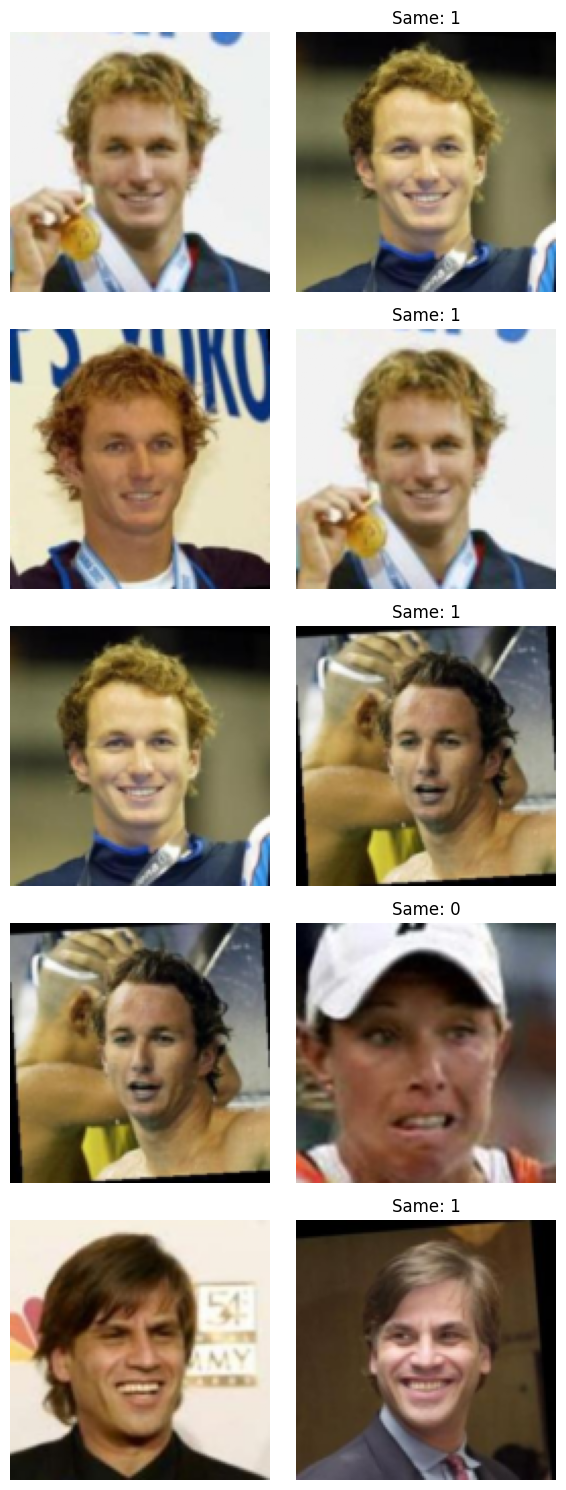

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5,2,
                         figsize=(6,15))

for i in range(5):

    img1, img2, label = siamese_dataset[i]

    axes[i,0].imshow(
        img1.permute(1,2,0)
    )

    axes[i,0].axis("off")

    axes[i,1].imshow(
        img2.permute(1,2,0)
    )

    axes[i,1].set_title(
        f"Same: {label}"
    )

    axes[i,1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch import nn

class MYNN(nn.Module):

    def __init__(self, input_features):
        super().__init__()

        # Shared Feature Extractor
        self.features =nn.Sequential(

            nn.Conv2d(input_features, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Dropout(0.0013709629937075727),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.0013709629937075727),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Dropout(0.0013709629937075727),
        )

        # Similarity Classifier
        self.classifier = nn.Sequential(

            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.007875641171471472),

            nn.Linear(256, 256//2),
            nn.ReLU(),
            nn.Dropout(0.007875641171471472),


            nn.Linear(256//2, 1),

        )

    def forward(self, img1, img2):

        # Extract features from image 1
        feat1 = self.features(img1)

        # Extract features from image 2
        feat2 = self.features(img2)

        # Flatten
        feat1 = torch.flatten(feat1, start_dim=1)
        feat2 = torch.flatten(feat2, start_dim=1)

        # Absolute difference
        diff = torch.abs(feat1 - feat2)

        # Classification
        output = self.classifier(diff)

        return output

In [ ]:
learning_rate = 8.783632673620091e-05
epochs = 80

In [ ]:
model = MYNN(input_features=3).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1.0440676387539795e-05)

In [ ]:
 # Training Loop
for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for img1, img2, labels in train_loader:
        img1 = img1.to(device)
        img2 = img2.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(
            img1,
            img2


        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * img1.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    print(
        f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}"
    )

Epoch 1/100, Loss: 0.6658
Epoch 2/100, Loss: 0.5731
Epoch 3/100, Loss: 0.5249
Epoch 4/100, Loss: 0.5158
Epoch 5/100, Loss: 0.4831
Epoch 6/100, Loss: 0.4732
Epoch 7/100, Loss: 0.4581
Epoch 8/100, Loss: 0.4418
Epoch 9/100, Loss: 0.4283
Epoch 10/100, Loss: 0.3957
Epoch 11/100, Loss: 0.3908
Epoch 12/100, Loss: 0.3853
Epoch 13/100, Loss: 0.3909
Epoch 14/100, Loss: 0.3801
Epoch 15/100, Loss: 0.3646
Epoch 16/100, Loss: 0.3575
Epoch 17/100, Loss: 0.3371
Epoch 18/100, Loss: 0.3135
Epoch 19/100, Loss: 0.3200
Epoch 20/100, Loss: 0.3285
Epoch 21/100, Loss: 0.3107
Epoch 22/100, Loss: 0.2942
Epoch 23/100, Loss: 0.2937
Epoch 24/100, Loss: 0.2927
Epoch 25/100, Loss: 0.2950
Epoch 26/100, Loss: 0.2821
Epoch 27/100, Loss: 0.2754
Epoch 28/100, Loss: 0.2696
Epoch 29/100, Loss: 0.2831
Epoch 30/100, Loss: 0.2562
Epoch 31/100, Loss: 0.2386
Epoch 32/100, Loss: 0.2389
Epoch 33/100, Loss: 0.2451
Epoch 34/100, Loss: 0.2460
Epoch 35/100, Loss: 0.2523
Epoch 36/100, Loss: 0.2186
Epoch 37/100, Loss: 0.2379
Epoch 38/1

In [ ]:
import torch

# Save only trained parameters
torch.save(
    model.state_dict(),
    "face_recognition_siamese_model.pth"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
len(test_dataset)

1833

In [ ]:
import zipfile
path='/content/imageFolder2.zip'
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall("/content/imageFolder2/")



In [ ]:
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])





test_data = datasets.ImageFolder(
    root="/content/imageFolder2/imageFolder2",
    transform=transform
)


In [ ]:
import torch
from torch import nn


# =====================================
# Siamese Network Architecture
# =====================================

class MYNN(nn.Module):

    def __init__(self, input_features):

        super().__init__()


        # Shared Feature Extractor
        self.features = nn.Sequential(

            nn.Conv2d(input_features, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Dropout(0.0013709629937075727),


            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.0013709629937075727),


            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Dropout(0.0013709629937075727)

        )



        # Similarity Classifier
        self.classifier = nn.Sequential(

            nn.Linear(
                128 * 16 * 16,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.007875641171471472),


            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.007875641171471472),


            nn.Linear(
                128,
                1
            )

        )



    def forward(self, img1, img2):


        # Image 1 feature extraction
        feat1 = self.features(img1)


        # Image 2 feature extraction
        feat2 = self.features(img2)



        # Flatten features

        feat1 = torch.flatten(
            feat1,
            start_dim=1
        )


        feat2 = torch.flatten(
            feat2,
            start_dim=1
        )



        # Difference between embeddings

        diff = torch.abs(
            feat1 - feat2
        )



        # Classification

        output = self.classifier(diff)


        return output





# =====================================
# Load Model
# =====================================


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)



model = MYNN(
    input_features=3
)



model.load_state_dict(

    torch.load(
        "face_recognition_siamese_model.pth",
        map_location=device
    )

)



model.to(device)


model.eval()



print("Model Loaded Successfully")





# =====================================
# Select Two Test Images
# =====================================


img1, label1 = test_data[3]

img2, label2 = test_data[2]



print("----------------------------")
print("Actual Labels")
print("Image 1 :", label1)
print("Image 2 :", label2)
print("----------------------------")




# =====================================
# Prepare Images
# =====================================


# Add batch dimension

img1 = img1.unsqueeze(0)

img2 = img2.unsqueeze(0)



# Move to GPU/CPU

img1 = img1.to(device)

img2 = img2.to(device)




# =====================================
# Prediction
# =====================================


with torch.no_grad():

    output = model(
        img1,
        img2
    )


    probability = torch.sigmoid(
        output
    )



probability = probability.item()



# =====================================
# Convert Probability to Label
# =====================================


if probability >= 0.5:

    prediction = "Same"

else:

    prediction = "Different"





print("----------------------------")

print(
    "Model Prediction:",
    prediction
)


print(
    "Similarity Probability:",
    round(probability * 100, 2),
    "%"
)


print("----------------------------")

Model Loaded Successfully
----------------------------
Actual Labels
Image 1 : 0
Image 2 : 0
----------------------------
----------------------------
Model Prediction: Same
Similarity Probability: 96.55 %
----------------------------


In [ ]:
img1, label1 = test_data[0]
img2, label2 = test_data[0]
print(label1, label2)


img1 = img1.to(device)
img2 = img2.to(device)

model.eval()

with torch.no_grad():
    outputs = model(img1, img2)

prob = torch.sigmoid(outputs)
print('same'if prob>=0.5 else 'different')
print("probability", prob)

0 0


NameError: name 'model' is not defined

In [ ]:
print(len(train_loader.dataset))

7329


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for img1, img2, labels in train_loader:

        img1 = img1.to(device)
        img2 = img2.to(device)
        labels = labels.float().to(device)

        outputs = model(img1, img2)

        # Convert logits to probabilities
        probs = torch.sigmoid(outputs)

        # Convert probabilities to 0 or 1
        preds = (probs >= 0.5).float()

        correct += (preds.squeeze() == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total

print(f"Training Accuracy: {accuracy:.2f}%")

Training Accuracy: 92.56%


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for img1, img2, labels in test_loader:

        img1 = img1.to(device)
        img2 = img2.to(device)

        labels = labels.float().to(device)

        outputs = model(img1, img2)

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).float()

        correct += (preds.squeeze() == labels).sum().item()

        total += labels.size(0)

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 90.45%


In [ ]:
!pip install optuna


In [ ]:
EPOCHS = 20

In [ ]:
import torch
from torch import nn

class MYNN(nn.Module):

    def __init__(
        self,
        input_features,
        conv_dropout,
        fc_dropout,
        hidden_dim,
        use_batchnorm
    ):
        super().__init__()

        bn1 = nn.BatchNorm2d(32) if use_batchnorm else nn.Identity()
        bn2 = nn.BatchNorm2d(64) if use_batchnorm else nn.Identity()
        bn3 = nn.BatchNorm2d(128) if use_batchnorm else nn.Identity()

        self.features = nn.Sequential(

            nn.Conv2d(input_features, 32, 3, padding=1),
            nn.ReLU(),
            bn1,
            nn.MaxPool2d(2),
            nn.Dropout(conv_dropout),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            bn2,
            nn.MaxPool2d(2),
            nn.Dropout(conv_dropout),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            bn3,
            nn.MaxPool2d(2),
            nn.Dropout(conv_dropout),
        )

        self.classifier = nn.Sequential(

            nn.Linear(128 * 16 * 16, hidden_dim),
            nn.ReLU(),
            nn.Dropout(fc_dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(fc_dropout),

            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, img1, img2):

        feat1 = self.features(img1)
        feat2 = self.features(img2)

        feat1 = torch.flatten(feat1, start_dim=1)
        feat2 = torch.flatten(feat2, start_dim=1)

        diff = torch.abs(feat1 - feat2)

        return self.classifier(diff)

In [ ]:
import optuna
from torch.utils.data import DataLoader

def objective(trial):

    lr = trial.suggest_float(
        "lr",
        1e-5,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [16, 32, 64]
    )

    conv_dropout = trial.suggest_float(
        "conv_dropout",
        0.0,
        0.4
    )

    fc_dropout = trial.suggest_float(
        "fc_dropout",
        0.0,
        0.6
    )

    hidden_dim = trial.suggest_categorical(
        "hidden_dim",
        [128, 256, 512]
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-2,
        log=True
    )

    use_batchnorm = trial.suggest_categorical(
        "use_batchnorm",
        [True, False]
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "AdamW"]
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = MYNN(
        input_features=3,
        conv_dropout=conv_dropout,
        fc_dropout=fc_dropout,
        hidden_dim=hidden_dim,
        use_batchnorm=use_batchnorm
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    EPOCHS = 20

    for epoch in range(EPOCHS):

        model.train()

        for img1, img2, labels in train_loader:

            img1 = img1.to(device)
            img2 = img2.to(device)

            labels = (
                labels
                .float()
                .unsqueeze(1)
                .to(device)
            )

            optimizer.zero_grad()

            outputs = model(
                img1,
                img2
            )

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for img1, img2, labels in test_loader:

            img1 = img1.to(device)
            img2 = img2.to(device)

            outputs = model(
                img1,
                img2
            )

            probs = torch.sigmoid(outputs)

            preds = (probs >= 0.5).float()

            correct += (
                preds.squeeze().cpu() == labels
            ).sum().item()

            total += labels.size(0)

    accuracy = correct / total

    return accuracy

In [ ]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=25
)

In [ ]:
[I 2026-06-14 09:09:57,850] Trial 11 finished with value: 0.855973813420622 and parameters: {'lr': 8.783632673620091e-05, 'batch_size': 64, 'conv_dropout': 0.0013709629937075727, 'fc_dropout': 0.007875641171471472, 'hidden_dim': 256, 'weight_decay': 1.0440676387539795e-05, 'use_batchnorm': True, 'optimizer': 'AdamW'}. Best is trial 11 with value: 0.855973813420622.